# Dá pra saber que vai atrasar antes de sair?

**Um modelo que prevê atraso de entrega usando só o que se sabe no momento da compra**

Kevin Moreira da Costa · [github.com/KevinCosta-AI](https://github.com/KevinCosta-AI)

---

### De onde isso vem

No [projeto anterior](https://github.com/KevinCosta-AI/nordeste-espera-mais) eu descobri que o Nordeste não atrasa mais por ser longe — a distância já está no prazo prometido. Atrasa porque a entrega ali é **imprevisível**.

Se é imprevisível, a pergunta seguinte é inevitável: **dá pra prever mesmo assim?**

### A pergunta

No segundo em que o cliente clica em comprar, o sistema sabe: para onde vai, de onde sai, quanto pesa, quanto custou o frete e quantos dias foram prometidos.

Com isso — e só com isso — dá pra dizer quais pedidos vão atrasar?

### Por que isso vale dinheiro

Se dá, a empresa pode agir **antes**: avisar o cliente, priorizar a coleta, trocar a transportadora. Depois que atrasou, só resta pedir desculpa.

---
## Passo 1 — Montar a base

Cinco tabelas. Pedidos e clientes eu já usei no projeto anterior; agora entram os itens (preço, frete, vendedor), os produtos (peso, categoria) e os vendedores (**de que estado sai a mercadoria**).

Esse último é o mais importante que eu não tinha antes: pedido que sai de São Paulo para o Ceará não é a mesma coisa que um que sai de Fortaleza para Fortaleza.

In [1]:
import pandas as pd
import numpy as np

BASE = "https://raw.githubusercontent.com/spdrio/Brazilian-E-Commerce-Public-Dataset-by-Olist/master/files/"

pedidos  = pd.read_csv(BASE + "olist_orders_dataset.csv",
                       parse_dates=["order_purchase_timestamp",
                                    "order_delivered_customer_date",
                                    "order_estimated_delivery_date"])
clientes = pd.read_csv(BASE + "olist_customers_dataset.csv")
itens    = pd.read_csv(BASE + "olist_order_items_dataset.csv", parse_dates=["shipping_limit_date"])
produtos = pd.read_csv(BASE + "olist_products_dataset.csv")
vendedor = pd.read_csv(BASE + "olist_sellers_dataset.csv")

for nome, t in [("pedidos",pedidos),("clientes",clientes),("itens",itens),
                ("produtos",produtos),("vendedores",vendedor)]:
    print(f"{nome:12s} {len(t):>7,} linhas".replace(",", "."))

pedidos       99.441 linhas
clientes      99.441 linhas
itens        112.650 linhas
produtos      32.951 linhas
vendedores     3.095 linhas


Um pedido pode ter vários itens, então preciso **resumir os itens em uma linha por pedido**: somo preço, frete e peso, conto quantos itens, e guardo a categoria e o estado do vendedor principal.

In [2]:
# alvo: o pedido chegou depois da data prometida?
df = (pedidos[pedidos.order_status == "delivered"]
      .dropna(subset=["order_delivered_customer_date", "order_estimated_delivery_date"])
      .copy())
df["atrasou"] = ((df.order_delivered_customer_date - df.order_estimated_delivery_date).dt.days > 0).astype(int)

# itens + produto + vendedor, resumidos por pedido
it = (itens
      .merge(produtos[["product_id", "product_category_name", "product_weight_g"]], on="product_id", how="left")
      .merge(vendedor[["seller_id", "seller_state"]], on="seller_id", how="left"))

resumo_itens = (it.groupby("order_id")
    .agg(preco=("price", "sum"),
         frete=("freight_value", "sum"),
         n_itens=("order_item_id", "count"),
         peso=("product_weight_g", "sum"),
         categoria=("product_category_name", "first"),
         uf_vendedor=("seller_state", "first"),
         limite_postagem=("shipping_limit_date", "max"))
    .reset_index())

df = (df.merge(resumo_itens, on="order_id", how="left")
        .merge(clientes[["customer_id", "customer_state"]], on="customer_id", how="left")
        .sort_values("order_purchase_timestamp")
        .reset_index(drop=True))

print(f"{len(df):,} pedidos entregues".replace(",", "."))
print(f"Atrasaram: {df.atrasou.mean():.2%}")
print(f"Período:   {df.order_purchase_timestamp.min():%d/%m/%Y} a {df.order_purchase_timestamp.max():%d/%m/%Y}")

96.470 pedidos entregues
Atrasaram: 6.77%
Período:   15/09/2016 a 29/08/2018


---
## Passo 2 — A regra que decide se o projeto presta

**Só posso usar informação que existe no momento da compra.**

Parece óbvio e é o erro mais comum em projeto de previsão. O dataset tem a data em que a transportadora coletou o pacote, por exemplo. Usar isso daria um modelo lindo e **inútil**: no instante da compra essa data não existe. O modelo estaria "prevendo" o passado.

Isso se chama **vazamento de dados**. Um modelo com vazamento parece excelente no teste e falha completamente na vida real.

Então listei o que entra e conferi cada coluna:

| Entra | Por quê |
|---|---|
| `dias_prometidos` | a promessa é feita na hora da compra |
| `folga_postagem` | prazo que o vendedor tem para despachar — combinado na compra |
| estado do cliente e do vendedor | conhecidos na hora |
| preço, frete, peso, nº de itens, categoria | do carrinho |
| mês, dia da semana, hora | do relógio |
| pedidos na semana | o quanto o sistema está congestionado |

**Fica de fora:** data de coleta, data de entrega, nota da avaliação. Tudo isso só existe depois.

In [3]:
df["dias_prometidos"] = (df.order_estimated_delivery_date - df.order_purchase_timestamp).dt.days
df["folga_postagem"]  = (df.limite_postagem            - df.order_purchase_timestamp).dt.days
df["mesma_uf"]        = (df.uf_vendedor == df.customer_state).astype(int)
df["categoria"]       = df.categoria.fillna("desconhecida")

df["mes"]        = df.order_purchase_timestamp.dt.month
df["dia_semana"] = df.order_purchase_timestamp.dt.dayofweek
df["hora"]       = df.order_purchase_timestamp.dt.hour

df["frete_por_preco"] = df.frete / df.preco.replace(0, np.nan)
df["peso_por_item"]   = df.peso  / df.n_itens.replace(0, np.nan)

semana = df.order_purchase_timestamp.dt.to_period("W")
df["pedidos_na_semana"] = semana.map(semana.value_counts())

print(f"Vendedor e cliente na mesma UF: {df.mesma_uf.mean():.1%} dos pedidos")
print(f"  atraso quando é a mesma UF:   {df[df.mesma_uf==1].atrasou.mean():.2%}")
print(f"  atraso quando é UF diferente: {df[df.mesma_uf==0].atrasou.mean():.2%}")

Vendedor e cliente na mesma UF: 36.0% dos pedidos
  atraso quando é a mesma UF:   4.50%
  atraso quando é UF diferente: 8.05%


Quase o dobro. Já dá pra ver que existe sinal aqui.

---
## Passo 3 — A armadilha da acurácia

Antes de treinar qualquer coisa, o modelo mais burro possível: **chutar que nenhum pedido atrasa.**

In [4]:
print(f"Acurácia do modelo que diz 'nunca atrasa': {1 - df.atrasou.mean():.1%}")
print(f"Atrasos que ele avisaria:                  0 de {df.atrasou.sum():,}".replace(",", "."))

Acurácia do modelo que diz 'nunca atrasa': 93.2%
Atrasos que ele avisaria:                  0 de 6.534


**93,2% de acerto.** E completamente inútil — nunca avisa ninguém.

É por isso que **acurácia não serve** para este problema. Só 6,8% dos pedidos atrasam, então qualquer modelo que quase sempre diga "não" parece ótimo no papel.

O que importa aqui são duas outras medidas:

- **Recall** — dos pedidos que realmente atrasaram, quantos o modelo pegou?
- **Precisão** — dos que ele apontou, quantos atrasaram de verdade?

As duas brigam entre si. Avisar mais gente pega mais atrasos e erra mais. Escolher esse ponto não é decisão técnica, é decisão de negócio — volto nisso no fim.

---
## Passo 4 — Separar por tempo, não por sorteio

O jeito padrão de dividir treino e teste é sortear linhas. **Aqui isso seria trapaça.**

Os dados vão de setembro de 2016 a agosto de 2018. Sorteando, o modelo treinaria com pedidos de agosto de 2018 para prever pedidos de janeiro de 2017 — veria o futuro. Na vida real você sempre prevê para frente.

Então corto no tempo: **treino no passado, teste no futuro.**

In [5]:
corte = df.order_purchase_timestamp.quantile(0.80)
treino = (df.order_purchase_timestamp <= corte).values
teste  = ~treino
y = df.atrasou.values

print(f"Corte: {corte:%d/%m/%Y}")
print(f"Treino: {treino.sum():,} pedidos  ·  atraso {y[treino].mean():.2%}".replace(",", "."))
print(f"Teste:  {teste.sum():,} pedidos  ·  atraso {y[teste].mean():.2%}".replace(",", "."))

Corte: 26/05/2018
Treino: 77.176 pedidos  ·  atraso 7.59%
Teste:  19.294 pedidos  ·  atraso 3.49%


Repara numa coisa que só apareceu por causa desse corte: **a taxa de atraso caiu de 7,6% para 3,5%** entre o começo e o fim do período.

O comportamento mudou ao longo do tempo. Um sorteio aleatório teria misturado os dois mundos e escondido isso — e eu teria achado que meu modelo era melhor do que é.

---
## Passo 5 — Dois modelos

Sempre começar pelo simples. Se o complicado não ganhar do simples, o simples vence — e é mais fácil de explicar, mais rápido e quebra menos.

**Regressão logística:** para cada característica, aprende um peso — o quanto ela empurra o risco pra cima ou pra baixo. Dá pra ler o que ele aprendeu.

**Gradient boosting:** centenas de arvorezinhas que se corrigem em sequência. Captura combinações que a logística não vê. Costuma ganhar.

`class_weight="balanced"` diz aos dois para levar os atrasos a sério, apesar de serem minoria.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix

NUMERICAS = ["dias_prometidos", "folga_postagem", "preco", "frete", "n_itens", "peso",
             "mesma_uf", "frete_por_preco", "peso_por_item",
             "mes", "dia_semana", "hora", "pedidos_na_semana"]
CATEGORICAS = ["customer_state", "uf_vendedor", "categoria"]

X = df[NUMERICAS + CATEGORICAS].copy()

preparo = ColumnTransformer([
    ("num", StandardScaler(), NUMERICAS),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=30), CATEGORICAS),
])

logistica = make_pipeline(preparo, LogisticRegression(max_iter=3000, class_weight="balanced"))
logistica.fit(X[treino].fillna(0), y[treino])
p_log = logistica.predict_proba(X[teste].fillna(0))[:, 1]

Xg = X.copy()
for col in CATEGORICAS:
    Xg[col] = Xg[col].astype("category")

boosting = HistGradientBoostingClassifier(
    max_iter=250, learning_rate=0.05, max_depth=4,
    categorical_features=CATEGORICAS, class_weight="balanced",
    random_state=0, early_stopping=True, validation_fraction=0.15)
boosting.fit(Xg[treino], y[treino])
p_boost = boosting.predict_proba(Xg[teste])[:, 1]

def avaliar(nome, p, limiar=0.5):
    yv = y[teste]
    yp = (p >= limiar).astype(int)
    tn, fp, fn, tp = confusion_matrix(yv, yp).ravel()
    print(f"{nome}")
    print(f"   AUC {roc_auc_score(yv, p):.3f}   precisão {precision_score(yv, yp, zero_division=0):.1%}"
          f"   recall {recall_score(yv, yp, zero_division=0):.1%}")
    print(f"   pegou {tp} de {tp+fn} atrasos · deu {fp} alarmes falsos\n")

avaliar("REGRESSÃO LOGÍSTICA", p_log)
avaliar("GRADIENT BOOSTING  ", p_boost)

REGRESSÃO LOGÍSTICA
   AUC 0.740   precisão 6.5%   recall 80.6%
   pegou 543 de 674 atrasos · deu 7807 alarmes falsos

GRADIENT BOOSTING  
   AUC 0.645   precisão 5.0%   recall 40.2%
   pegou 271 de 674 atrasos · deu 5146 alarmes falsos



---
## Passo 6 — O simples ganhou, e isso não é acaso

**Logística 0,740 · Boosting 0,645.**

*(AUC é a chance de o modelo dar nota de risco maior a um pedido que atrasou do que a um que não atrasou. 0,5 é moeda jogada pro alto; 1,0 é perfeito.)*

Não era o esperado. Boosting quase sempre ganha de regressão logística em dado tabular. Testei tirando features, mudando profundidade e taxa de aprendizado — a logística ganhou em todas as combinações.

A explicação está no Passo 4: **a taxa de atraso caiu pela metade entre treino e teste.** O boosting aprendeu combinações finas do período antigo, quando atrasar era comum. A logística, por ser mais simples, aprendeu tendências grosseiras — e tendência grossa sobrevive à mudança.

É a lição prática de sobreajuste: **modelo mais esperto não é modelo melhor quando o mundo muda.**

Sigo com a logística. Além de mais precisa aqui, ela deixa ler o que aprendeu — que é o próximo passo.

---
## Passo 7 — O que o modelo aprendeu sozinho

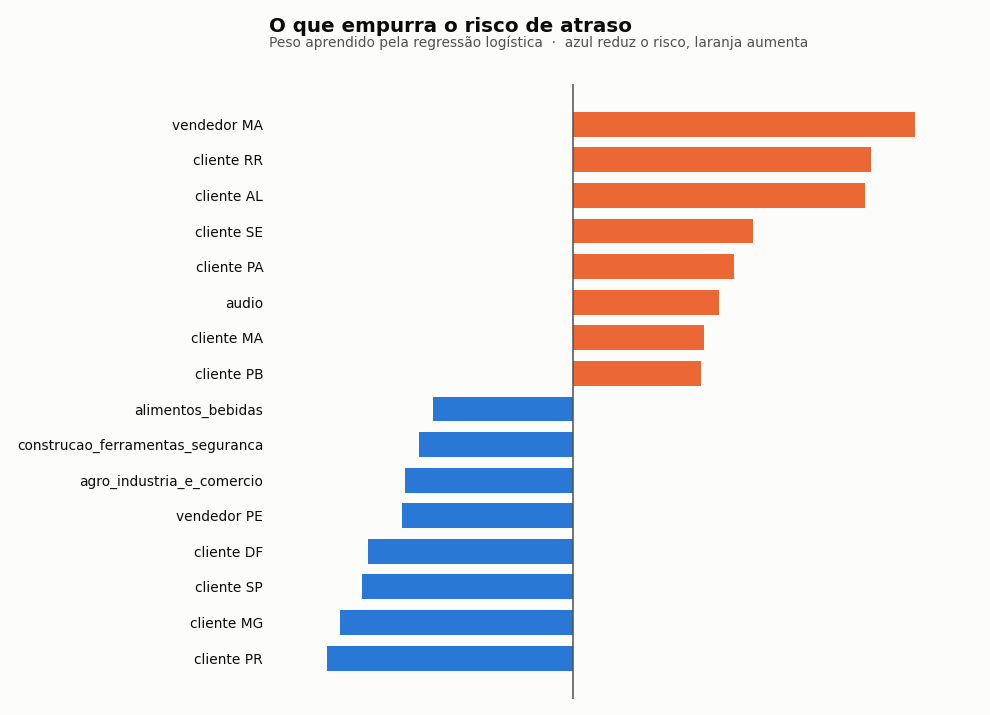

In [7]:
import matplotlib.pyplot as plt

nomes = (list(preparo.named_transformers_["num"].feature_names_in_) +
         list(preparo.named_transformers_["cat"].get_feature_names_out(CATEGORICAS)))
pesos = pd.Series(logistica[-1].coef_[0], index=nomes).sort_values()
extremos = pd.concat([pesos.head(8), pesos.tail(8)])

TINTA="#0b0b0b"; TINTA_FRACA="#52514e"; AZUL="#2a78d6"; LARANJA="#eb6834"; FUNDO="#fcfcfb"

fig, ax = plt.subplots(figsize=(9, 6.5), facecolor=FUNDO)
ax.set_facecolor(FUNDO)
cores = [AZUL if v < 0 else LARANJA for v in extremos.values]
ax.barh(range(len(extremos)), extremos.values, color=cores, height=0.7)
ax.set_yticks(range(len(extremos)))
ax.set_yticklabels([n.replace("customer_state_", "cliente ").replace("uf_vendedor_", "vendedor ")
                     .replace("categoria_", "") for n in extremos.index], fontsize=9, color=TINTA)
ax.axvline(0, color=TINTA_FRACA, lw=1)
ax.set_title("O que empurra o risco de atraso", fontsize=13, color=TINTA,
             pad=34, loc="left", fontweight="bold")
ax.text(0, 1.06, "Peso aprendido pela regressão logística  ·  azul reduz o risco, laranja aumenta",
        transform=ax.transAxes, fontsize=9, color=TINTA_FRACA)
ax.set_xticks([])
for lado in ["top","right","bottom","left"]: ax.spines[lado].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.margins(x=0.10)
plt.tight_layout(); plt.show()

Ninguém contou nada disso ao modelo. Ele leu 77 mil pedidos e concluiu.

**Aumentando o risco:** Roraima, Alagoas, Sergipe, Pará, Maranhão, Paraíba. E vendedor do Maranhão, o peso mais alto de todos.

**Reduzindo:** Paraná, Minas Gerais, São Paulo, Distrito Federal.

Entre as variáveis numéricas, as que mais pesam são `dias_prometidos` (**-0,62** — quanto mais dias a loja pede, menor a chance de estourar), `pedidos_na_semana` (**+0,48** — semana congestionada atrasa mais) e `mesma_uf` (**-0,42** — vendedor no mesmo estado do cliente atrasa menos). Todas fazem sentido, e o modelo chegou nelas sozinho.

Mas o padrão real só aparece olhando **todos** os estados de uma vez.

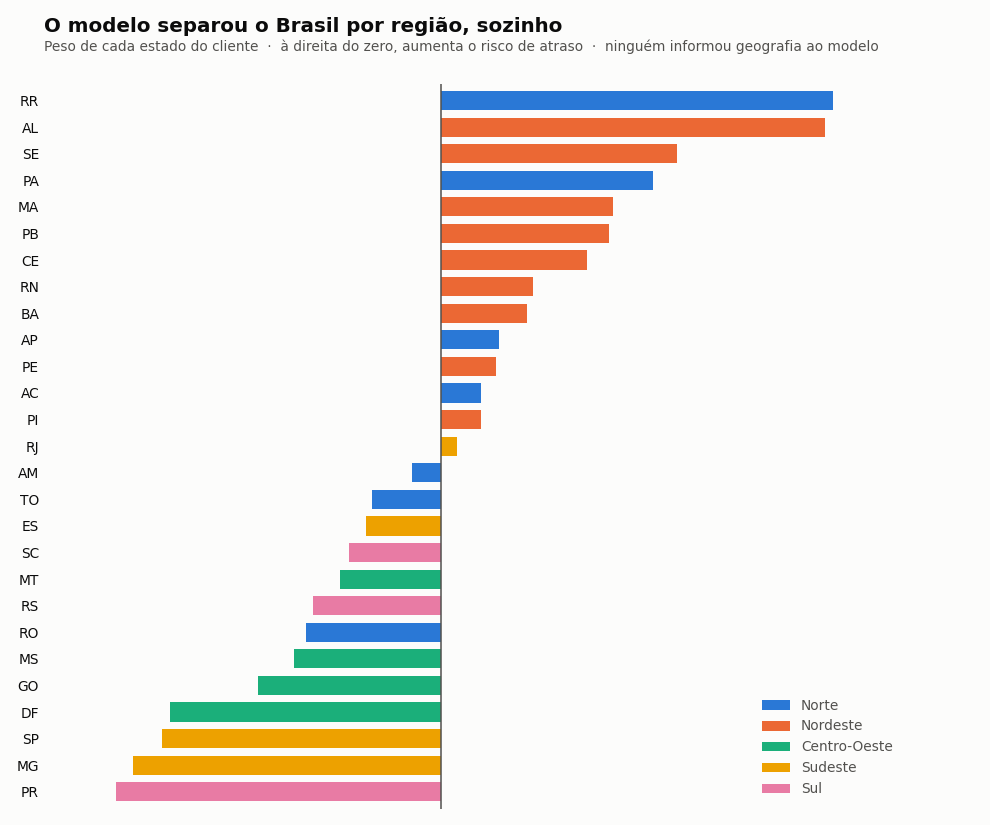

In [8]:
REGIOES = {
    "Norte":        ["AC","AP","AM","PA","RO","RR","TO"],
    "Nordeste":     ["AL","BA","CE","MA","PB","PE","PI","RN","SE"],
    "Centro-Oeste": ["DF","GO","MT","MS"],
    "Sudeste":      ["ES","MG","RJ","SP"],
    "Sul":          ["PR","RS","SC"],
}
uf_regiao = {uf: reg for reg, ufs in REGIOES.items() for uf in ufs}

peso_uf = pesos[[n for n in pesos.index if n.startswith("customer_state_")]].copy()
peso_uf.index = [n.replace("customer_state_", "") for n in peso_uf.index]
peso_uf = peso_uf.sort_values()
regiao_de = [uf_regiao[uf] for uf in peso_uf.index]

# cores categoricas em ordem fixa, uma por regiao
COR = {"Norte": "#2a78d6", "Nordeste": "#eb6834", "Centro-Oeste": "#1baf7a",
       "Sudeste": "#eda100", "Sul": "#e87ba4"}

fig, ax = plt.subplots(figsize=(9, 7.5), facecolor=FUNDO)
ax.set_facecolor(FUNDO)
ax.barh(range(len(peso_uf)), peso_uf.values,
        color=[COR[r] for r in regiao_de], height=0.72)
ax.set_yticks(range(len(peso_uf)))
ax.set_yticklabels(peso_uf.index, fontsize=9, color=TINTA)
ax.axvline(0, color=TINTA_FRACA, lw=1)

from matplotlib.patches import Patch
legendas = [Patch(facecolor=cor, label=regiao) for regiao, cor in COR.items()]
leg = ax.legend(handles=legendas, loc="lower right", frameon=False, fontsize=9)
for t_ in leg.get_texts(): t_.set_color(TINTA_FRACA)

ax.set_title("O modelo separou o Brasil por região, sozinho",
             fontsize=13, color=TINTA, pad=34, loc="left", fontweight="bold")
ax.text(0, 1.045, "Peso de cada estado do cliente  ·  à direita do zero, aumenta o risco de atraso  ·  ninguém informou geografia ao modelo",
        transform=ax.transAxes, fontsize=9, color=TINTA_FRACA)
ax.set_xticks([])
for lado in ["top","right","bottom","left"]: ax.spines[lado].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.margins(x=0.10, y=0.01)
plt.tight_layout(); plt.show()

In [9]:
positivos = peso_uf[peso_uf > 0].index
print("Estados que AUMENTAM o risco, por região:")
for regiao in REGIOES:
    lista = [uf for uf in positivos if uf_regiao[uf] == regiao]
    if lista:
        print(f"  {regiao:14s} {len(lista)} de {len(REGIOES[regiao])}: {', '.join(sorted(lista))}")

Estados que AUMENTAM o risco, por região:
  Norte          4 de 7: AC, AP, PA, RR
  Nordeste       9 de 9: AL, BA, CE, MA, PB, PE, PI, RN, SE
  Sudeste        1 de 4: RJ


**Olha o gráfico e a lista.**

Todos os **9 de 9** estados do **Nordeste** puxam o risco pra cima. No **Norte**, 4 de 7. Do outro lado do zero, os que mais reduzem são São Paulo, Minas, Paraná e o Distrito Federal.

O modelo **não sabe geografia**. Não recebeu mapa, latitude, distância nem a palavra "região". Recebeu siglas de duas letras, que pra ele são rótulos sem significado — CE poderia ser uma cor, uma marca ou um número.

E mesmo assim, ao olhar 77 mil entregas, ele reordenou o Brasil e reconstruiu a divisão regional do IBGE sozinho.

E aqui os dois projetos se encontram. No [projeto anterior](https://github.com/KevinCosta-AI/nordeste-espera-mais) eu achei isso na mão, comparando médias e percentis. Aqui um modelo estatístico, partindo do zero e sem saber daquela análise, chegou ao mesmo lugar.

Quando dois caminhos independentes levam à mesma conclusão, provavelmente a conclusão existe.

---
## Passo 8 — A pergunta que um gestor faria

Ninguém decide nada com AUC. A pergunta real é:

> *"Se a gente fosse avisar o cliente antes, quantos avisos falsos daria para pegar cada atraso de verdade?"*

Para responder, ordeno os pedidos do teste do menos para o mais arriscado, divido em dez grupos iguais e olho quantos atrasaram de verdade em cada um.

In [10]:
risco = pd.DataFrame({"probabilidade": p_log, "atrasou": y[teste]})
risco["grupo"] = pd.qcut(risco.probabilidade, 10, labels=range(1, 11))

decis = (risco.groupby("grupo", observed=True)
         .agg(pedidos=("atrasou", "size"), atrasos=("atrasou", "sum"), taxa=("atrasou", "mean")))
decis["taxa_%"] = (decis.taxa * 100).round(1)
decis["% do total de atrasos"] = (decis.atrasos / risco.atrasou.sum() * 100).round(1)
decis[["pedidos", "atrasos", "taxa_%", "% do total de atrasos"]]

,pedidos,atrasos,taxa_%,% do total de atrasos
grupo,,,,
1,1930,3,0.2,0.4
2,1929,11,0.6,1.6
3,1929,18,0.9,2.7
4,1930,28,1.5,4.2
5,1929,36,1.9,5.3
6,1929,58,3.0,8.6
7,1930,89,4.6,13.2
8,1929,136,7.1,20.2
9,1929,141,7.3,20.9


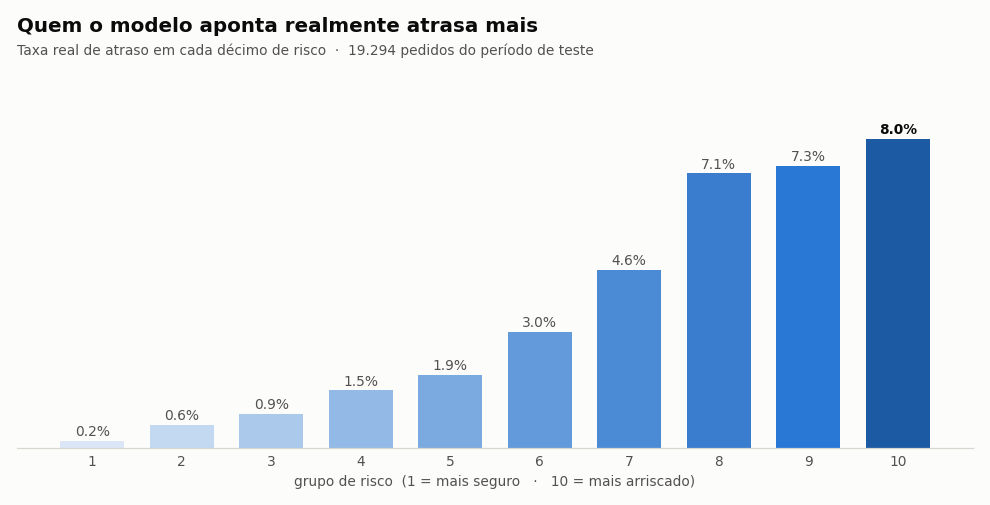

In [11]:
AZUIS = ["#dbe7f6","#c3d8f1","#abc9eb","#93b9e6","#7baae0","#639adb","#4b8bd5","#3a7ccd","#2a78d6","#1c5ba3"]

fig, ax = plt.subplots(figsize=(9, 4.6), facecolor=FUNDO)
ax.set_facecolor(FUNDO)
ax.bar(range(1, 11), decis["taxa_%"].values, color=AZUIS, width=0.72)
for i, v in enumerate(decis["taxa_%"].values, start=1):
    ax.text(i, v + 0.15, f"{v}%", ha="center", fontsize=9,
            color=TINTA if i == 10 else TINTA_FRACA, fontweight="bold" if i == 10 else "normal")

ax.set_title("Quem o modelo aponta realmente atrasa mais", fontsize=13, color=TINTA,
             pad=34, loc="left", fontweight="bold")
ax.text(0, 1.08, "Taxa real de atraso em cada décimo de risco  ·  19.294 pedidos do período de teste",
        transform=ax.transAxes, fontsize=9, color=TINTA_FRACA)
ax.set_xlabel("grupo de risco  (1 = mais seguro   ·   10 = mais arriscado)", fontsize=9, color=TINTA_FRACA)
ax.set_xticks(range(1, 11)); ax.set_yticks([])
for lado in ["top","right","left"]: ax.spines[lado].set_visible(False)
ax.spines["bottom"].set_color("#d8d7d0")
ax.tick_params(axis="x", length=0, labelsize=9, colors=TINTA_FRACA)
ax.margins(y=0.18)
plt.tight_layout(); plt.show()

In [12]:
print("Se a empresa quisesse avisar os clientes de maior risco:\n")
for fatia in [0.05, 0.10, 0.20, 0.30]:
    limiar = np.quantile(p_log, 1 - fatia)
    marcado = p_log >= limiar
    pegou = marcado[y[teste] == 1].sum() / (y[teste] == 1).sum()
    acerto = y[teste][marcado].mean()
    n_avisos = f"{marcado.sum():,}".replace(",", ".")
    print(f"  avisando os {fatia:>3.0%} mais arriscados  ->  pega {pegou:.0%} de todos os atrasos"
          f"   ({n_avisos} avisos, {acerto:.0%} certos)")

Se a empresa quisesse avisar os clientes de maior risco:

  avisando os  5% mais arriscados  ->  pega 14% de todos os atrasos   (965 avisos, 10% certos)
  avisando os 10% mais arriscados  ->  pega 23% de todos os atrasos   (1.930 avisos, 8% certos)
  avisando os 20% mais arriscados  ->  pega 44% de todos os atrasos   (3.859 avisos, 8% certos)
  avisando os 30% mais arriscados  ->  pega 64% de todos os atrasos   (5.788 avisos, 7% certos)


---
## O que eu achei

**O modelo funciona, e o número que prova isso não é a acurácia.**

Entre o décimo mais seguro e o décimo mais arriscado, a taxa real de atraso vai de **0,2% a 8,0%** — **quarenta vezes maior**. O modelo não sabe quais pedidos vão atrasar, mas sabe muito bem onde procurar.

**Avisando 30% dos pedidos, pegaria 64% de todos os atrasos.** Se cada aviso custa quase nada — uma notificação — vale a pena. Se custa caro — um brinde, um cupom — não vale, e aí você aperta para os 5% mais arriscados e pega 14%.

Essa é a decisão do negócio, não do modelo. O que o modelo faz é colocar o número na mesa.

**O que eu não vou fingir:** com AUC 0,740 e precisão de 6,5%, a maioria dos avisos seria alarme falso. Isso serve para priorizar operação — coletar antes, escolher outra transportadora. Não serve para prometer prazo diferente ao cliente.

**Três coisas que eu aprendi e que não estavam no plano:**

1. **Acurácia de 93% pode ser inútil.** O modelo burro atinge isso sem fazer nada.
2. **O modelo mais simples ganhou do mais complexo** — porque o mundo mudou entre treino e teste, e o simples se apoia em tendências que sobrevivem à mudança.
3. **O corte no tempo revelou uma queda pela metade na taxa de atraso** que um sorteio aleatório teria escondido.

---

## O que veio depois

**[Parte 3 — O que o cliente reclama quando a entrega atrasa?](https://github.com/KevinCosta-AI/o-que-o-cliente-reclama)** Os clientes escreveram **39.748 comentários** nas avaliações, em português. Li todos sem abrir nenhum à mão.

**E a resposta contraria este projeto aqui.** Eu passei o projeto inteiro tentando prever *quando* o pedido atrasa. Os comentários mostram que 44% das reclamações não são sobre atraso — são sobre o pedido **nunca ter chegado**. O cliente não está impaciente: está sem saber onde está a compra dele.

---

*Dados: [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) · 2016–2018 · uso público.*
*A trilogia: [1 — O Nordeste espera mais?](https://github.com/KevinCosta-AI/nordeste-espera-mais) · **2 — este** · [3 — O que o cliente reclama?](https://github.com/KevinCosta-AI/o-que-o-cliente-reclama)*